#**ML Challenge - IEEE SB GEHU | Fault Detection System**


## **Problem Statement -**
We are given sensor data from an embedded device monitoring system.
The goal is to predict whether a device is operating normally or has a fault.

- **Input:** 47 numerical features (F01–F47) representing operational parameters
- **Target:** Binary Classification
  - Class 0 → Normal device
  - Class 1 → Faulty device

## Evaluation Metrics
- Accuracy
- F1-Score

## Dataset
- Training set: ~43,776 rows
- Test set: ~11,000 rows
- No missing values
- Clean numerical data


In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML - Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# ML - Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
!pip install optuna

# Utility
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 12.2 MB/s eta 0:00:00
All libraries loaded successfully!


In [2]:
from google.colab import files
uploaded = files.upload()

# Load datasets
train_df = pd.read_csv('TRAIN.csv')
test_df = pd.read_csv('TEST.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

Saving TEST.csv to TEST.csv
Saving TRAIN.csv to TRAIN.csv
Train shape: (43776, 48)
Test shape:  (10944, 48)


In [3]:
print("let's Explore Training Data")
print(train_df.head())

print(f"Total Rows     : {train_df.shape[0]}")
print(f"Total Features : {train_df.shape[1] - 1}")
print(f"Target Column  : Class")



let's Explore Training Data
        F01       F02       F03       F04       F05       F06       F07  \
0  0.185570  0.004568  0.005362  0.003335  0.005415  0.004895  0.012764   
1  0.369536  0.003983  0.003386  0.004902  0.007570  0.012136  0.118050   
2  0.602510  0.008442  0.012961  0.012870  0.046885  0.115401  0.065688   
3  0.347957  0.064721  0.013611  0.011541  0.006492  0.008690  0.013192   
4  0.233653  0.012217  0.010088  0.022095  0.026040  0.015062  0.016063   

        F08       F09       F10  ...       F39        F40       F41       F42  \
0  0.120138  0.140450  3.361753  ...  0.041526  -0.230857  0.003310  0.042250   
1  0.323925  0.132093  2.766117  ... -0.141285  -6.222857  0.834177  0.227968   
2  0.306677  0.498805  4.521201  ...  0.011334  10.335251 -0.276614 -0.198900   
3  0.164553  0.298665  3.170847  ...  0.190479   2.864912 -1.921939  0.891690   
4  0.084648  0.213367  8.150943  ...  0.203164   0.001812 -0.092731  0.005280   

        F43       F44       F45   

In [4]:

print("Missing Values:", train_df.isnull().sum().sum())
print("Duplicate Rows:", train_df.duplicated().sum())

Missing Values: 0
Duplicate Rows: 738


#Data Visualization

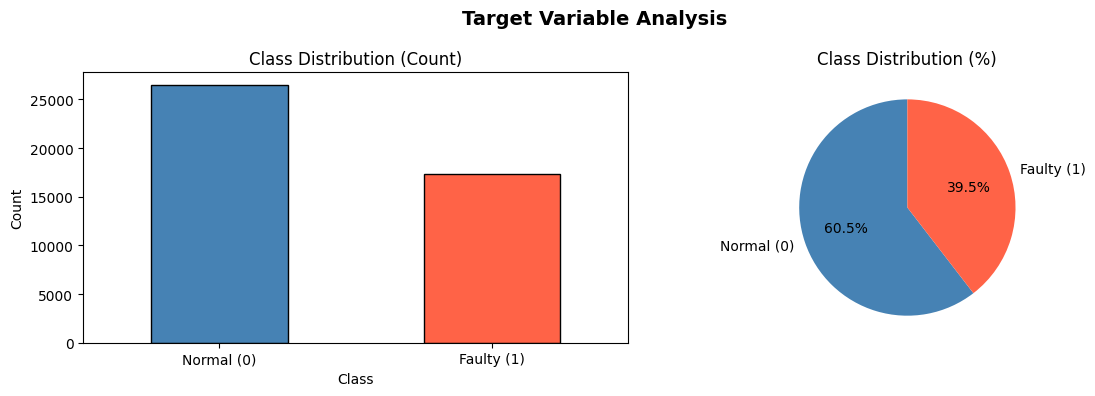

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
train_df['Class'].value_counts().plot(kind='bar', ax=axes[0],
                                       color=['steelblue','tomato'],
                                       edgecolor='black')
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Normal (0)', 'Faulty (1)'], rotation=0)

# Pie chart
train_df['Class'].value_counts().plot(kind='pie', ax=axes[1],
                                       labels=['Normal (0)', 'Faulty (1)'],
                                       colors=['steelblue','tomato'],
                                       autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution (%)')
axes[1].set_ylabel('')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [6]:
print(f"Total rows in dataset: {train_df.shape[0]}")
print(f"Duplicate rows found : {train_df.duplicated().sum()}")

# Show some duplicate examples
print("Sample duplicate rows:")
display(train_df[train_df.duplicated(keep=False)].head(6))

Total rows in dataset: 43776
Duplicate rows found : 738
Sample duplicate rows:


,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F39,F40,F41,F42,F43,F44,F45,F46,F47,Class
10,0.196319,0.014600,0.031199,0.015208,0.044037,0.037686,0.012134,0.040577,0.178802,3.193827,...,-0.028266,0.004237,0.032287,0.003509,-0.007149,-0.000318,-0.010811,-0.000372,-0.004171,0
62,0.179647,0.005647,0.004629,0.007229,0.011659,0.030882,0.026408,0.150397,0.088137,3.616270,...,-0.027735,1.382911,-0.254149,-0.025731,0.006527,-0.001569,-0.000615,0.000525,0.004746,0
66,0.133845,0.004167,0.003772,0.014128,0.033262,0.026480,0.016806,0.092926,0.083416,3.732108,...,0.078743,-0.103736,0.072217,0.001761,-0.003352,-0.009735,0.008379,-0.000976,0.062804,0
71,0.389131,0.038281,0.081337,0.039566,0.170557,0.263395,0.068344,0.055329,0.188542,3.399937,...,0.004048,0.009235,0.012514,0.005267,-0.007212,0.003176,-0.010161,0.003166,0.003378,0
115,0.217727,0.008742,0.018664,0.013556,0.039785,0.036643,0.011016,0.040487,0.205208,3.293167,...,-0.015849,-0.003954,0.041980,0.000178,0.019561,-0.002089,-0.010826,0.000418,-0.001552,0
151,0.249986,0.009927,0.019878,0.021876,0.059775,0.040936,0.013832,0.049433,0.231632,3.476902,...,0.002110,-0.601708,0.028990,0.008240,0.005379,0.003068,-0.000825,-0.000261,-0.000264,0


In [7]:
# Some Examples of duplicate rows
dupes = train_df[train_df.duplicated(keep=False)]
dupes_sorted = dupes.sort_values(by=list(dupes.columns))
print(f"Total flagged duplicate rows: {len(dupes_sorted)}")
display(dupes_sorted.head(6))


Total flagged duplicate rows: 1476


,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F39,F40,F41,F42,F43,F44,F45,F46,F47,Class
8340,0.100187,0.008092,0.006158,0.006025,0.011022,0.026112,0.014401,0.076279,0.055418,3.729902,...,-0.009397,0.187679,-0.042405,-0.021162,0.006103,0.007695,0.003564,-0.000698,0.029735,0
22602,0.100187,0.008092,0.006158,0.006025,0.011022,0.026112,0.014401,0.076279,0.055418,3.729902,...,-0.009397,0.187679,-0.042405,-0.021162,0.006103,0.007695,0.003564,-0.000698,0.029735,0
11418,0.100534,0.003446,0.004828,0.005769,0.008806,0.031524,0.014382,0.079317,0.049692,3.545151,...,-0.039760,0.049382,-0.058685,0.016881,-0.021035,-0.003263,0.004864,-0.000097,-0.047981,0
19540,0.100534,0.003446,0.004828,0.005769,0.008806,0.031524,0.014382,0.079317,0.049692,3.545151,...,-0.039760,0.049382,-0.058685,0.016881,-0.021035,-0.003263,0.004864,-0.000097,-0.047981,0
12748,0.101535,0.008142,0.005793,0.006919,0.011049,0.025964,0.016440,0.078246,0.054562,3.578338,...,0.009976,0.226536,-0.011660,-0.012418,0.006366,0.002582,-0.000559,-0.000646,0.027721,0
29017,0.101535,0.008142,0.005793,0.006919,0.011049,0.025964,0.016440,0.078246,0.054562,3.578338,...,0.009976,0.226536,-0.011660,-0.012418,0.006366,0.002582,-0.000559,-0.000646,0.027721,0


Bottom 10 features by variance (lowest = least useful):
F20    3.190920e-08
F02    3.844218e-04
F03    5.064260e-04
F04    2.573057e-03
F44    2.956151e-02
F05    3.549231e-02
F45    4.064701e-02
F46    4.085655e-02
F29    6.144509e-02
F07    1.155650e-01
dtype: float64


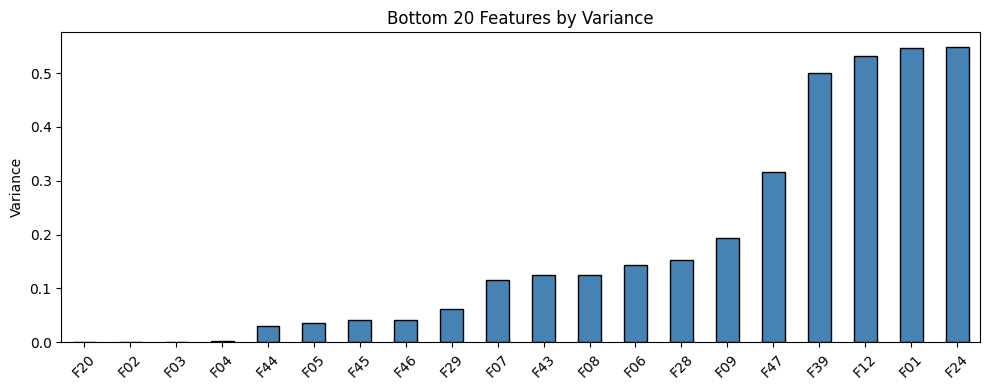

In [8]:
# Calculate variance of every feature
variances = train_df.drop('Class', axis=1).var().sort_values()

print("Bottom 10 features by variance (lowest = least useful):")
print(variances.head(10))

# Visualize
plt.figure(figsize=(10, 4))
variances.head(20).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Bottom 20 Features by Variance')
plt.ylabel('Variance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
corr_matrix = train_df.drop('Class', axis=1).corr().abs()

# Find highly correlated pairs
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[row, col])
                   for col in upper.columns
                   for row in upper.index
                   if upper.loc[row, col] > 0.95]

print(f"Highly correlated pairs (correlation > 0.95): {len(high_corr_pairs)}")
print(f"\n{'Feature A':<10} {'Feature B':<10} {'Correlation'}")
print("-" * 35)
for a, b, corr in high_corr_pairs:
    print(f"{a:<10} {b:<10} {corr:.4f}")

Highly correlated pairs (correlation > 0.95): 6

Feature A  Feature B  Correlation
-----------------------------------
F24        F04        0.9746
F25        F05        0.9740
F26        F06        0.9963
F27        F07        0.9969
F28        F08        0.9844
F29        F09        0.9895


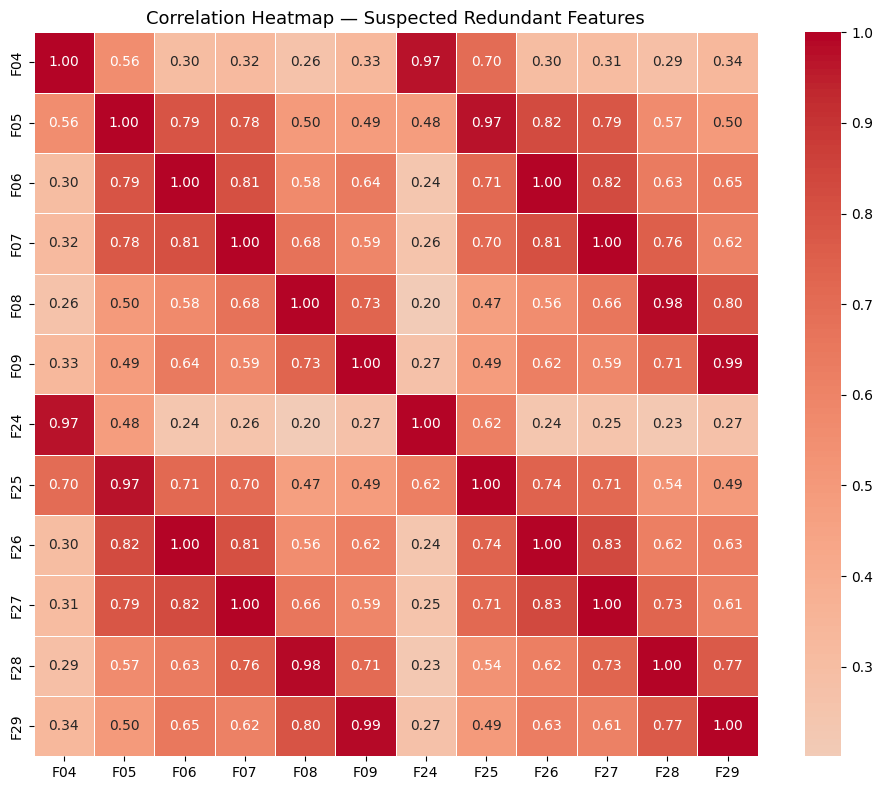

In [10]:
# Focus heatmap on the suspicious pairs we found
focus_cols = ['F04','F05','F06','F07','F08','F09',
              'F24','F25','F26','F27','F28','F29']

plt.figure(figsize=(10, 8))
sns.heatmap(
    train_df[focus_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Correlation Heatmap — Suspected Redundant Features', fontsize=13)
plt.tight_layout()
plt.show()

Features with extreme outliers (max >> mean):


,mean,max,std,max_to_mean_ratio
F20,-1.731999e-07,0.021508,0.000179,123467.330800
F42,-8.900363e-05,9.374269,1.103486,105323.383468
F44,1.007074e-03,9.139964,0.171935,9075.749017
F47,-6.779667e-03,40.818882,0.562031,6020.779190
F45,4.599006e-03,18.623611,0.201611,4049.484818
F39,2.347677e-02,89.378571,0.707224,3807.106385
F43,3.215180e-03,11.399358,0.354742,3545.479719
F46,3.981015e-03,8.960172,0.202130,2250.725039
F30,4.269205e+00,9340.001953,58.724624,2187.761639
F41,5.845757e-03,10.907778,1.631328,1865.930507


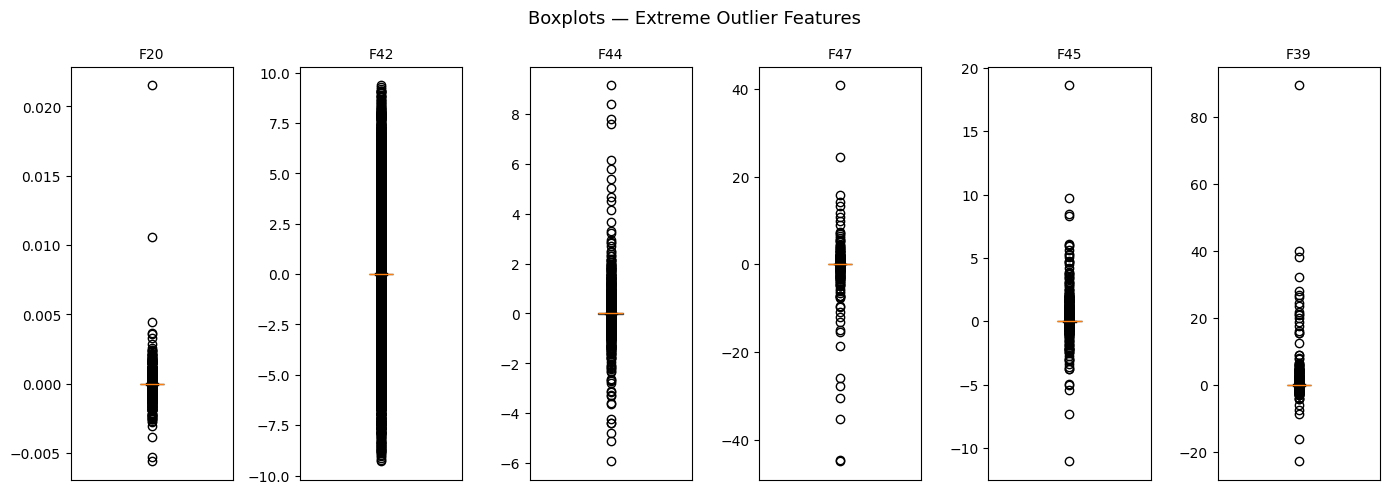

In [11]:
# Features with extreme outliers
stats = train_df.drop('Class', axis=1).describe().T
stats['max_to_mean_ratio'] = stats['max'] / (stats['mean'].abs() + 1e-9)
outlier_features = stats[stats['max_to_mean_ratio'] > 100].sort_values('max_to_mean_ratio', ascending=False)

print("Features with extreme outliers (max >> mean):")
display(outlier_features[['mean', 'max', 'std', 'max_to_mean_ratio']])

# Boxplot for top 6 most extreme
top_outlier_cols = outlier_features.head(6).index.tolist()
plt.figure(figsize=(14, 5))
for i, col in enumerate(top_outlier_cols):
    plt.subplot(1, 6, i+1)
    plt.boxplot(train_df[col].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
    plt.title(col, fontsize=10)
    plt.xticks([])
plt.suptitle('Boxplots — Extreme Outlier Features', fontsize=13)
plt.tight_layout()
plt.show()

#Data Cleaning

In [12]:
print(f"Shape before: {train_df.shape}")
train_df = train_df.drop_duplicates()
print(f"Shape after : {train_df.shape}")
print(f"Removed {738} duplicate rows")

Shape before: (43776, 48)
Shape after : (43038, 48)
Removed 738 duplicate rows


In [13]:
# F20  → near zero variance (carries no information)
# F24-F29 → highly correlated with F04-F09 (redundant)

cols_to_drop = ['F20', 'F24', 'F25', 'F26', 'F27', 'F28', 'F29']

train_df = train_df.drop(columns=cols_to_drop, errors='ignore')
test_df  = test_df.drop(columns=cols_to_drop, errors='ignore')

print(f"Dropped: {cols_to_drop}")
print(f"Remaining features: {train_df.shape[1] - 1}")

Dropped: ['F20', 'F24', 'F25', 'F26', 'F27', 'F28', 'F29']
Remaining features: 40


In [14]:
X = train_df.drop(columns=['Class'])
y = train_df['Class']

# Keep ID for final submission
test_ids = test_df['ID']
X_test   = test_df.drop(columns=['ID'])

print(f" X shape      : {X.shape}")
print(f" y shape      : {y.shape}")
print(f" X_test shape : {X_test.shape}")

 X shape      : (43038, 40)
 y shape      : (43038,)
 X_test shape : (10944, 40)


In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,     # 80% training, 20% validation
    random_state=42,   # reproducibility
    stratify=y         # maintain 60/40 ratio in both splits
)

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"\nClass ratio in training:")
print(y_train.value_counts(normalize=True).mul(100).round(1))
print(f"\nClass ratio in validation:")
print(y_val.value_counts(normalize=True).mul(100).round(1))

X_train : (34430, 40)
X_val   : (8608, 40)

Class ratio in training:
Class
0    59.8
1    40.2
Name: proportion, dtype: float64

Class ratio in validation:
Class
0    59.8
1    40.2
Name: proportion, dtype: float64


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
import time

# Dictionary of models to compare
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM'                 : SVC(random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=300, random_state=42,
                                          n_jobs=-1, verbosity=0, eval_metric='logloss'),
    'LightGBM'            : LGBMClassifier(n_estimators=300, random_state=42,
                                           n_jobs=-1, verbosity=-1)
}

results = []

print("Training and evaluating all models...")
print("This will take a few minutes (SVM is slow)...\n")

for name, model in models.items():
    start = time.time()

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_val)

    # Score
    acc  = accuracy_score(y_val, y_pred) * 100
    f1   = f1_score(y_val, y_pred) * 100
    elapsed = time.time() - start

    results.append({
        'Model'        : name,
        'Accuracy'     : acc,
        'F1 Score'     : f1,
        'Training Time': f"{elapsed:.1f}s"
    })

    print(f"{name:<25} Accuracy: {acc:.2f}%  F1: {f1:.2f}%  Time: {elapsed:.1f}s")

print("\nAll models evaluated!")

Training and evaluating all models...
This will take a few minutes (SVM is slow)...

Logistic Regression       Accuracy: 73.64%  F1: 58.18%  Time: 14.5s
Decision Tree             Accuracy: 93.91%  F1: 92.43%  Time: 10.3s
Random Forest             Accuracy: 97.89%  F1: 97.32%  Time: 34.3s
SVM                       Accuracy: 70.41%  F1: 47.50%  Time: 89.9s
XGBoost                   Accuracy: 98.59%  F1: 98.24%  Time: 4.6s
LightGBM                  Accuracy: 98.28%  F1: 97.85%  Time: 7.1s

All models evaluated!



            Model Selection Comparison
Model                       Accuracy   F1 Score       Time
-----------------------------------------------------------------
XGBoost                       98.59%     98.24%       4.6s
LightGBM                      98.28%     97.85%       7.1s
Random Forest                 97.89%     97.32%      34.3s
Decision Tree                 93.91%     92.43%      10.3s
Logistic Regression           73.64%     58.18%      14.5s
SVM                           70.41%     47.50%      89.9s


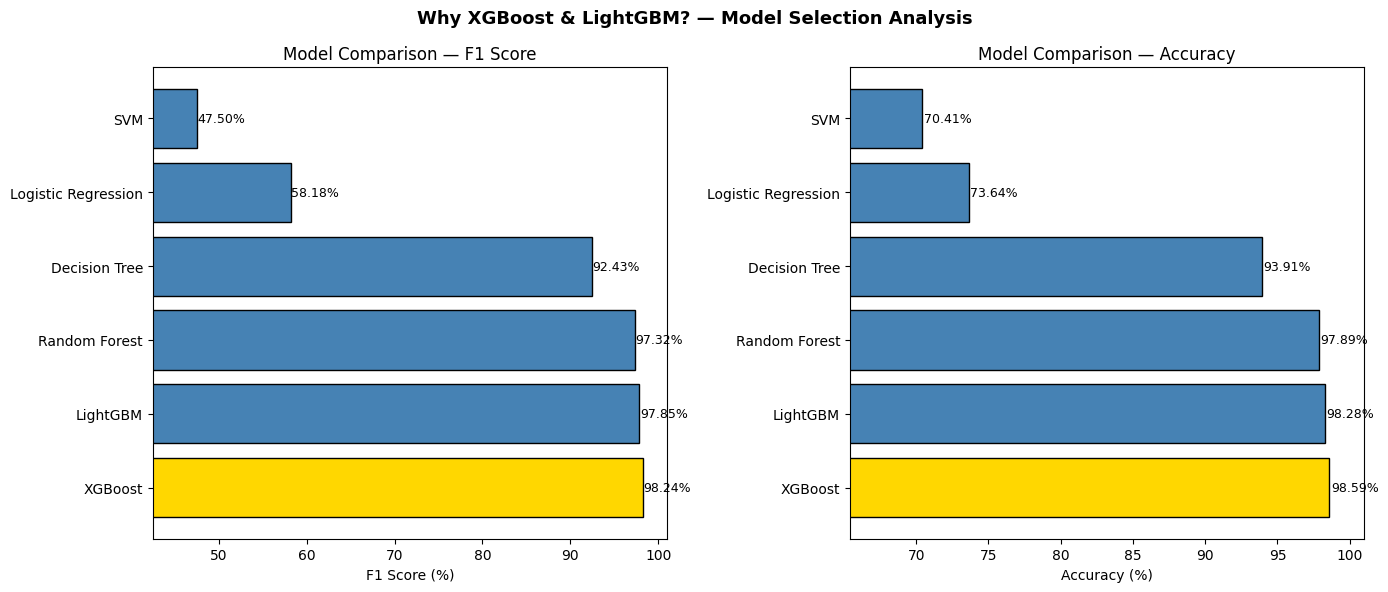


Best Model: XGBoost
   F1 Score : 98.24%
   Accuracy : 98.59%

This is why we chose XGBoost & LightGBM!


In [17]:
results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)

print("\n" + "=" * 65)
print("            Model Selection Comparison")
print("=" * 65)
print(f"{'Model':<25} {'Accuracy':>10} {'F1 Score':>10} {'Time':>10}")
print("-" * 65)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<25} {row['Accuracy']:>9.2f}% {row['F1 Score']:>9.2f}% {row['Training Time']:>10}")
print("=" * 65)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# F1 Score comparison
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
axes[0].barh(results_df['Model'], results_df['F1 Score'],
             color=colors, edgecolor='black')
axes[0].set_xlabel('F1 Score (%)')
axes[0].set_title('Model Comparison — F1 Score')
axes[0].set_xlim(results_df['F1 Score'].min() - 5, 101)
for i, (val, name) in enumerate(zip(results_df['F1 Score'], results_df['Model'])):
    axes[0].text(val + 0.1, i, f'{val:.2f}%', va='center', fontsize=9)

# Accuracy comparison
axes[1].barh(results_df['Model'], results_df['Accuracy'],
             color=colors, edgecolor='black')
axes[1].set_xlabel('Accuracy (%)')
axes[1].set_title('Model Comparison — Accuracy')
axes[1].set_xlim(results_df['Accuracy'].min() - 5, 101)
for i, (val, name) in enumerate(zip(results_df['Accuracy'], results_df['Model'])):
    axes[1].text(val + 0.1, i, f'{val:.2f}%', va='center', fontsize=9)

plt.suptitle('Why XGBoost & LightGBM? — Model Selection Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print winner
best_model = results_df.iloc[0]
print(f"\nBest Model: {best_model['Model']}")
print(f"   F1 Score : {best_model['F1 Score']:.2f}%")
print(f"   Accuracy : {best_model['Accuracy']:.2f}%")
print(f"\nThis is why we chose XGBoost & LightGBM!")


#Training Time :-

In [18]:
# Initialize model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=26465/17311,  # handle class imbalance
    random_state=42,
    n_jobs=-1,                     # use all CPU cores
    eval_metric='logloss',
    verbosity=0
)

# Train
print("Training XGBoost...")
xgb_model.fit(X_train, y_train)
print("Training complete!")

Training XGBoost...
Training complete!


In [19]:
# Predictions on validation set
y_pred_xgb = xgb_model.predict(X_val)

# Scores
acc_xgb = accuracy_score(y_val, y_pred_xgb)
f1_xgb  = f1_score(y_val, y_pred_xgb)

print("=" * 40)
print("       XGBoost Baseline Results")
print("=" * 40)
print(f"  Accuracy : {acc_xgb*100:.2f}%")
print(f"  F1 Score : {f1_xgb*100:.2f}%")
print("=" * 40)

print("\nDetailed Classification Report:")
print(classification_report(y_val, y_pred_xgb,
      target_names=['Normal (0)', 'Faulty (1)']))

       XGBoost Baseline Results
  Accuracy : 98.27%
  F1 Score : 97.84%

Detailed Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.98      0.99      0.99      5146
  Faulty (1)       0.98      0.97      0.98      3462

    accuracy                           0.98      8608
   macro avg       0.98      0.98      0.98      8608
weighted avg       0.98      0.98      0.98      8608



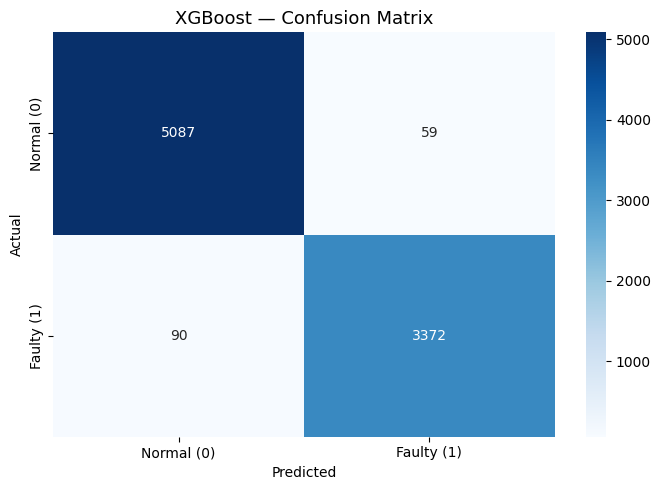


True Normal  (Correct Normal predictions) : 5087
 True Faulty  (Correct Faulty predictions) : 3372
 False Alarm  (Normal predicted as Faulty) : 59
 Missed Fault (Faulty predicted as Normal) : 90


In [20]:
cm = confusion_matrix(y_val, y_pred_xgb)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Faulty (1)'],
            yticklabels=['Normal (0)', 'Faulty (1)'])
plt.title('XGBoost — Confusion Matrix', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Explain the confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Normal  (Correct Normal predictions) : {tn}")
print(f" True Faulty  (Correct Faulty predictions) : {tp}")
print(f" False Alarm  (Normal predicted as Faulty) : {fp}")
print(f" Missed Fault (Faulty predicted as Normal) : {fn}")

Top 15 Most Important Features:


,Feature,Importance
0,F01,0.088794
18,F19,0.060741
8,F09,0.054759
28,F36,0.043078
20,F22,0.040784
4,F05,0.040116
7,F08,0.035796
9,F10,0.032159
22,F30,0.030362
5,F06,0.030219


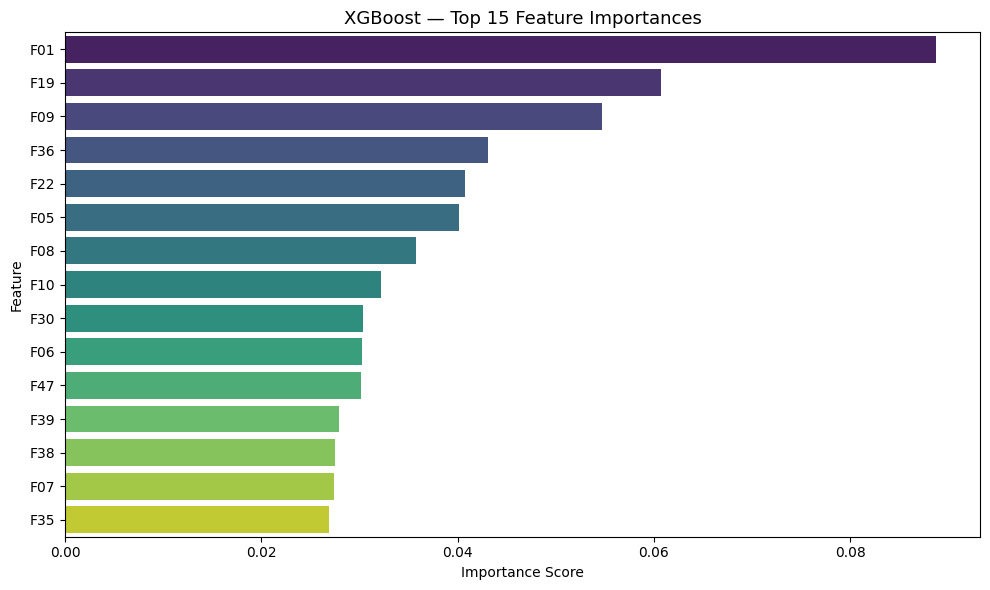

In [21]:
# Get feature importances
importance_df = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 15 Most Important Features:")
display(importance_df.head(15))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15),
            x='Importance', y='Feature',
            palette='viridis')
plt.title('XGBoost — Top 15 Feature Importances', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

#Let's Fine Tune it

In [22]:
# Initialize model
lgb_model = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=26465/17311,  # handle class imbalance
    random_state=42,
    n_jobs=-1,
    verbosity=-1                   # suppress warnings
)

# Train
print("Training LightGBM...")
lgb_model.fit(X_train, y_train)
print("Training complete!")

Training LightGBM...
Training complete!


In [23]:
# Predictions
y_pred_lgb = lgb_model.predict(X_val)

# Scores
acc_lgb = accuracy_score(y_val, y_pred_lgb)
f1_lgb  = f1_score(y_val, y_pred_lgb)

print("=" * 40)
print("       LightGBM Baseline Results")
print("=" * 40)
print(f"  Accuracy : {acc_lgb*100:.2f}%")
print(f"  F1 Score : {f1_lgb*100:.2f}%")
print("=" * 40)

print("\nDetailed Classification Report:")
print(classification_report(y_val, y_pred_lgb,
      target_names=['Normal (0)', 'Faulty (1)']))


       LightGBM Baseline Results
  Accuracy : 98.29%
  F1 Score : 97.87%

Detailed Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.98      0.99      0.99      5146
  Faulty (1)       0.98      0.97      0.98      3462

    accuracy                           0.98      8608
   macro avg       0.98      0.98      0.98      8608
weighted avg       0.98      0.98      0.98      8608



         Model Comparison Summary
Model             Accuracy   F1 Score
---------------------------------------------
XGBoost             98.27%     97.84%
LightGBM            98.29%     97.87%


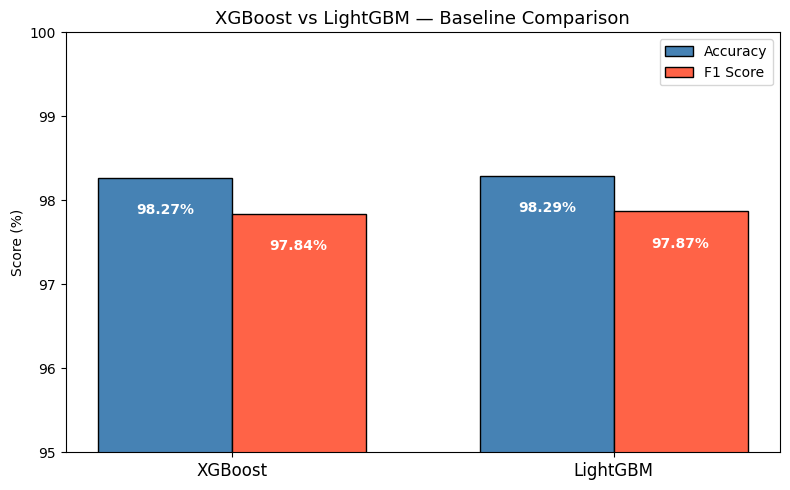

In [24]:
print("=" * 45)
print("         Model Comparison Summary")
print("=" * 45)
print(f"{'Model':<15} {'Accuracy':>10} {'F1 Score':>10}")
print("-" * 45)
print(f"{'XGBoost':<15} {acc_xgb*100:>9.2f}% {f1_xgb*100:>9.2f}%")
print(f"{'LightGBM':<15} {acc_lgb*100:>9.2f}% {f1_lgb*100:>9.2f}%")
print("=" * 45)

# Visual comparison
models   = ['XGBoost', 'LightGBM']
accuracy = [acc_xgb*100, acc_lgb*100]
f1scores = [f1_xgb*100, f1_lgb*100]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, accuracy, width,
               label='Accuracy', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, f1scores, width,
               label='F1 Score', color='tomato', edgecolor='black')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() - 0.3,
            f'{bar.get_height():.2f}%',
            ha='center', va='top',
            fontsize=10, color='white', fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() - 0.3,
            f'{bar.get_height():.2f}%',
            ha='center', va='top',
            fontsize=10, color='white', fontweight='bold')

ax.set_ylim(95, 100)
ax.set_ylabel('Score (%)')
ax.set_title('XGBoost vs LightGBM — Baseline Comparison', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier # Import XGBClassifier as it's used in objective_xgb
from sklearn.metrics import f1_score # Import f1_score as it's used in objective_xgb

def objective_xgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight' : 26465/17311,
        'random_state'     : 42,
        'n_jobs'           : -1,
        'verbosity'        : 0,
        'eval_metric'      : 'logloss'
    }

    model = XGBClassifier(**params)

    # Single split instead of 5-fold (3x faster)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    return f1_score(y_val, y_pred)

sampler = optuna.samplers.TPESampler(seed=42)
study_xgb = optuna.create_study(direction='maximize', sampler=sampler)
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)

[I 2026-03-04 10:39:16,618] A new study created in memory with name: no-name-e23e9630-a059-4dd8-bbf6-9ce80d3569f8


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-04 10:39:32,044] Trial 0 finished with value: 0.984306887532694 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2}. Best is trial 0 with value: 0.984306887532694.
[I 2026-03-04 10:39:38,676] Trial 1 finished with value: 0.9715033439953474 and parameters: {'n_estimators': 123, 'max_depth': 9, 'learning_rate': 0.07725378389307355, 'subsample': 0.8540362888980227, 'colsample_bytree': 0.5102922471479012, 'min_child_weight': 10}. Best is trial 0 with value: 0.984306887532694.
[I 2026-03-04 10:39:42,157] Trial 2 finished with value: 0.8838118142191492 and parameters: {'n_estimators': 433, 'max_depth': 4, 'learning_rate': 0.01855998084649059, 'subsample': 0.5917022549267169, 'colsample_bytree': 0.6521211214797689, 'min_child_weight': 6}. Best is trial 0 with value: 0.984306887532694.
[I 2026-03-04 10:39:45,010] Trial 3 finished with value: 0.96486

In [26]:
def objective_lgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0, 5),
        'scale_pos_weight' : 26465/17311,
        'random_state'     : 42,
        'n_jobs'           : -1,
        'verbosity'        : -1
    }

    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    return f1_score(y_val, y_pred)

print("Tuning LightGBM (30 trials)...")
sampler   = optuna.samplers.TPESampler(seed=42)
study_lgb = optuna.create_study(direction='maximize', sampler=sampler)
study_lgb.optimize(objective_lgb, n_trials=30, show_progress_bar=True)

print(f"\nLightGBM Tuning Complete!")
print(f"   Best F1 Score : {study_lgb.best_value*100:.2f}%")
print(f"   Best Params   : {study_lgb.best_params}")

[I 2026-03-04 10:42:39,695] A new study created in memory with name: no-name-05780a20-910c-411d-994a-fe58300e1df6


Tuning LightGBM (30 trials)...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-04 10:42:41,978] Trial 0 finished with value: 0.9725036179450073 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_samples': 19, 'num_leaves': 27, 'reg_alpha': 4.330880728874676, 'reg_lambda': 3.005575058716044}. Best is trial 0 with value: 0.9725036179450073.
[I 2026-03-04 10:42:43,644] Trial 1 finished with value: 0.9645390070921985 and parameters: {'n_estimators': 383, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'min_child_samples': 22, 'num_leaves': 44, 'reg_alpha': 1.5212112147976886, 'reg_lambda': 2.6237821581611893}. Best is trial 0 with value: 0.9725036179450073.
[I 2026-03-04 10:42:48,761] Trial 2 finished with value: 0.9630059480632526 and parameters: {'n_estimators': 273, 'max_depth': 5, 'learning_rate': 0.08012737503998542, 'subsample': 0.569746930326021, 'co

In [27]:
# XGBoost with best params
print("Training tuned XGBoost...")
best_xgb = XGBClassifier(
    **study_xgb.best_params,
    scale_pos_weight=26465/17311,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    eval_metric='logloss'
)
best_xgb.fit(X_train, y_train)
print("Tuned XGBoost ready!")

# LightGBM with best params
print("\nTraining tuned LightGBM...")
best_lgb = LGBMClassifier(
    **study_lgb.best_params,
    scale_pos_weight=26465/17311,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
best_lgb.fit(X_train, y_train)
print("Tuned LightGBM ready!")

Training tuned XGBoost...
Tuned XGBoost ready!

Training tuned LightGBM...
Tuned LightGBM ready!


In [28]:
# Tuned predictions
y_pred_xgb_tuned = best_xgb.predict(X_val)
y_pred_lgb_tuned = best_lgb.predict(X_val)

acc_xgb_tuned = accuracy_score(y_val, y_pred_xgb_tuned)
f1_xgb_tuned  = f1_score(y_val, y_pred_xgb_tuned)
acc_lgb_tuned = accuracy_score(y_val, y_pred_lgb_tuned)
f1_lgb_tuned  = f1_score(y_val, y_pred_lgb_tuned)

print("=" * 55)
print("           Full Model Comparison")
print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>10} {'F1 Score':>10}")
print("-" * 55)
print(f"{'XGBoost (baseline)':<25} {acc_xgb*100:>9.2f}% {f1_xgb*100:>9.2f}%")
print(f"{'LightGBM (baseline)':<25} {acc_lgb*100:>9.2f}% {f1_lgb*100:>9.2f}%")
print("-" * 55)
print(f"{'XGBoost (tuned)':<25} {acc_xgb_tuned*100:>9.2f}% {f1_xgb_tuned*100:>9.2f}%")
print(f"{'LightGBM (tuned)':<25} {acc_lgb_tuned*100:>9.2f}% {f1_lgb_tuned*100:>9.2f}%")
print("=" * 55)

           Full Model Comparison
Model                       Accuracy   F1 Score
-------------------------------------------------------
XGBoost (baseline)            98.27%     97.84%
LightGBM (baseline)           98.29%     97.87%
-------------------------------------------------------
XGBoost (tuned)               98.84%     98.55%
LightGBM (tuned)              98.70%     98.37%


In [29]:
# Get probabilities from both tuned models
prob_xgb = best_xgb.predict_proba(X_val)[:, 1]
prob_lgb  = best_lgb.predict_proba(X_val)[:, 1]

# Average probabilities (soft voting)
avg_probs       = (prob_xgb + prob_lgb) / 2
y_pred_ensemble = (avg_probs >= 0.5).astype(int)

# Scores
acc_ensemble = accuracy_score(y_val, y_pred_ensemble)
f1_ensemble  = f1_score(y_val, y_pred_ensemble)

print("=" * 55)
print("           FINAL Model Comparison")
print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>10} {'F1 Score':>10}")
print("-" * 55)
print(f"{'XGBoost (baseline)':<25} {acc_xgb*100:>9.2f}% {f1_xgb*100:>9.2f}%")
print(f"{'LightGBM (baseline)':<25} {acc_lgb*100:>9.2f}% {f1_lgb*100:>9.2f}%")
print("-" * 55)
print(f"{'XGBoost (tuned)':<25} {acc_xgb_tuned*100:>9.2f}% {f1_xgb_tuned*100:>9.2f}%")
print(f"{'LightGBM (tuned)':<25} {acc_lgb_tuned*100:>9.2f}% {f1_lgb_tuned*100:>9.2f}%")
print("-" * 55)
print(f"{'ENSEMBLE (XGB+LGB)':<25} {acc_ensemble*100:>9.2f}% {f1_ensemble*100:>9.2f}%")
print("=" * 55)

           FINAL Model Comparison
Model                       Accuracy   F1 Score
-------------------------------------------------------
XGBoost (baseline)            98.27%     97.84%
LightGBM (baseline)           98.29%     97.87%
-------------------------------------------------------
XGBoost (tuned)               98.84%     98.55%
LightGBM (tuned)              98.70%     98.37%
-------------------------------------------------------
ENSEMBLE (XGB+LGB)            98.84%     98.55%


In [30]:
# Give more weight to better model (XGBoost)
weights = [0.6, 0.4]  # 60% XGBoost, 40% LightGBM

weighted_probs       = (weights[0] * prob_xgb) + (weights[1] * prob_lgb)
y_pred_weighted      = (weighted_probs >= 0.5).astype(int)

acc_weighted = accuracy_score(y_val, y_pred_weighted)
f1_weighted  = f1_score(y_val, y_pred_weighted)

print(f"Weighted Ensemble (60/40) → Accuracy: {acc_weighted*100:.2f}% | F1: {f1_weighted*100:.2f}%")
print(f"Equal Ensemble    (50/50) → Accuracy: {acc_ensemble*100:.2f}% | F1: {f1_ensemble*100:.2f}%")
print(f"XGBoost alone             → Accuracy: {acc_xgb_tuned*100:.2f}% | F1: {f1_xgb_tuned*100:.2f}%")

# Pick best
scores = {
    'XGBoost alone'   : f1_xgb_tuned,
    'Equal Ensemble'  : f1_ensemble,
    'Weighted Ensemble': f1_weighted
}
best_approach = max(scores, key=scores.get)
print(f"\n Best approach: {best_approach} with F1: {scores[best_approach]*100:.2f}%")


Weighted Ensemble (60/40) → Accuracy: 98.82% | F1: 98.52%
Equal Ensemble    (50/50) → Accuracy: 98.84% | F1: 98.55%
XGBoost alone             → Accuracy: 98.84% | F1: 98.55%

 Best approach: Equal Ensemble with F1: 98.55%


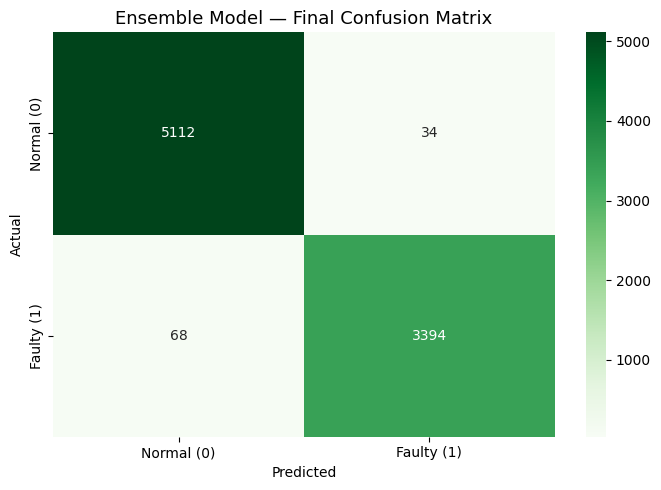


True Normal   : 5112
True Faulty   : 3394
False Alarm   : 34
Missed Faults : 68

Improvement from baseline:
  Missed Faults : 90 → 68 (22 fewer missed faults!)
  False Alarms  : 59 → 34 (25 fewer false alarms!)


In [31]:
# Use best approach for confusion matrix
cm = confusion_matrix(y_val, y_pred_weighted)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal (0)', 'Faulty (1)'],
            yticklabels=['Normal (0)', 'Faulty (1)'])
plt.title('Ensemble Model — Final Confusion Matrix', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Normal   : {tn}")
print(f"True Faulty   : {tp}")
print(f"False Alarm   : {fp}")
print(f"Missed Faults : {fn}")
print(f"\nImprovement from baseline:")
print(f"  Missed Faults : 90 → {fn} ({90-fn} fewer missed faults!)")
print(f"  False Alarms  : 59 → {fp} ({59-fp} fewer false alarms!)")

In [32]:
# Get probabilities from both tuned models for the test set
prob_xgb_test = best_xgb.predict_proba(X_test)[:, 1]
prob_lgb_test  = best_lgb.predict_proba(X_test)[:, 1]

# Average probabilities (soft voting) for the test set
avg_probs_test       = (prob_xgb_test + prob_lgb_test) / 2
y_pred_ensemble_test = (avg_probs_test >= 0.5).astype(int)

# Create the submission DataFrame
submission = pd.DataFrame({
    'ID': test_ids,
    'Class': y_pred_ensemble_test
})

# Check TEST.csv structure
print("TEST.csv structure:")
print(f"   Rows    : {len(test_df)}")
print(f"   Columns : {list(test_df.columns)}")
display(test_df.head(5))

# Check submission matches exactly
print("\nVerifying FINAL.csv format:")
print(f"   Total rows in TEST.csv   : {len(test_df)}")
print(f"   Total rows in FINAL.csv  : {len(submission)}")
print(f"   Row count match          : {len(test_df) == len(submission)}")

# Check ID order matches exactly
print(f"\n   First 5 IDs in TEST.csv  : {test_df['ID'].head().tolist()}")
print(f"   First 5 IDs in FINAL.csv : {submission['ID'].head().tolist()}")
print(f"   ID order match           : {test_df['ID'].tolist() == submission['ID'].tolist()}")

# Check column names match expected format
print(f"\n   Columns in FINAL.csv     : {list(submission.columns)}")
print(f"   Expected                 : ['ID', 'Class']")

# Preview final submission
print("\nFinal submission preview:")
display(submission.head(10))


TEST.csv structure:
   Rows    : 10944
   Columns : ['ID', 'F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F21', 'F22', 'F23', 'F30', 'F31', 'F32', 'F33', 'F34', 'F35', 'F36', 'F37', 'F38', 'F39', 'F40', 'F41', 'F42', 'F43', 'F44', 'F45', 'F46', 'F47']


,ID,F01,F02,F03,F04,F05,F06,F07,F08,F09,...,F38,F39,F40,F41,F42,F43,F44,F45,F46,F47
0,1,0.277497,0.011515,0.009359,0.011706,0.015613,0.063679,0.021114,0.152000,0.220904,...,2.974426,0.009399,0.015668,0.001999,-0.000937,0.010605,-0.001117,0.043216,-0.000077,-0.040124
1,2,0.158754,0.013861,0.020935,0.002451,0.005939,0.006830,0.006934,0.117209,0.103432,...,2.619811,0.029324,-0.003211,0.037691,-0.083697,0.006595,0.044507,0.007523,-0.000283,-0.007837
2,3,0.504418,0.009106,0.007395,0.009073,0.029486,0.086782,0.122499,0.179376,0.445695,...,4.411972,-0.171520,-0.866895,-0.070657,0.034070,-0.000493,-0.011417,-0.004844,-0.034235,-0.001832
3,4,0.556345,0.005370,0.005670,0.005167,0.013731,0.014570,0.014776,0.522296,0.189882,...,2.709162,0.044236,19.880789,-2.144453,-1.792552,-0.034137,-0.051971,-0.085069,-0.000110,0.045889
4,5,0.128356,0.010014,0.016144,0.003891,0.004472,0.005297,0.007538,0.075874,0.101176,...,2.872020,-0.056908,0.006535,0.070059,-0.007989,0.004089,-0.000206,-0.011331,0.000441,-0.025263



Verifying FINAL.csv format:
   Total rows in TEST.csv   : 10944
   Total rows in FINAL.csv  : 10944
   Row count match          : True

   First 5 IDs in TEST.csv  : [1, 2, 3, 4, 5]
   First 5 IDs in FINAL.csv : [1, 2, 3, 4, 5]
   ID order match           : True

   Columns in FINAL.csv     : ['ID', 'Class']
   Expected                 : ['ID', 'Class']

Final submission preview:


,ID,Class
0,1,1
1,2,0
2,3,1
3,4,0
4,5,0
5,6,1
6,7,0
7,8,1
8,9,1
9,10,0


In [33]:
submission.to_csv('FINAL.csv', index=False)
print("\nFINAL.csv saved!")

from google.colab import files
files.download('FINAL.csv')
print("Download started! Check your downloads folder!")


FINAL.csv saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started! Check your downloads folder!
